# Birdseye Camera Calibration

In [1]:
from science_jubilee.Machine import Machine
from science_jubilee.peripherals.BirdseyeCamera import BirdseyeCamera

machine = Machine(address="192.168.1.2")
birdseye = BirdseyeCamera.from_config('BirdseyeCamera_config.json')
birdseye.attach(machine)

/Users/blairsubbaraman/research/pose26/science-jubilee/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


0
response in connect:  [True, True, True, True]
Calibration loaded from /Users/blairsubbaraman/research/pose26/science-jubilee/src/science_jubilee/peripherals/configs/user/camera_calibration-cher.npz


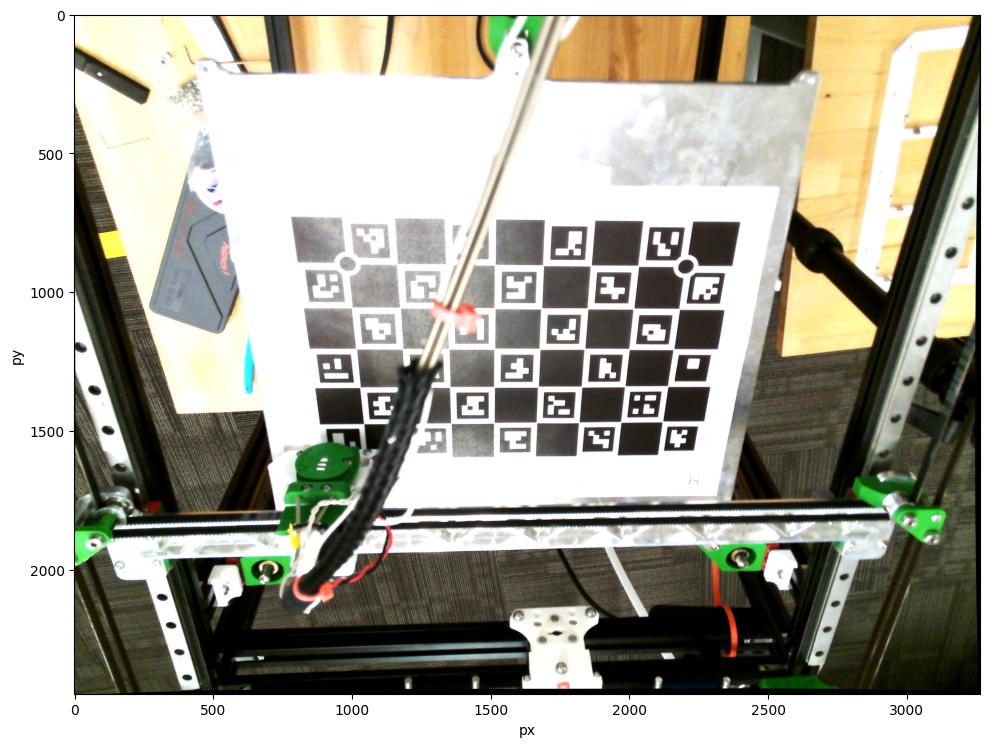

In [4]:
# We can take pictures and look at them
frame = birdseye.get_frame()
birdseye.show_frame(frame)

In [6]:
# Then we can move to a pixel!
birdseye.move_to_pixel(1500, 1000)

In [ ]:
# Add some detection here

In [ ]:
# Run calibration WITH PHYSICAL INPUT
# Make sure square_mm matches printed dimensions

# if the y axis is facing the wrong way after this, try
# flipping the y_sign between 1/-1 and try again
square_size_mm = 27 # update if needed
rvec, tvec = cam.calibrate_3d_charuco(
    boards=[(corner_a, corner_b)], y_sign=-1,
    board_cols=9, board_rows=6, square_mm=square_size_mm,
    save_path="camera_calibration-cher.npz",
    pixel_axes=([0, -1, 0], [-1, 0, 0]),  # px+ → machine -Y, py+ → machine -X
)


In [ ]:
def calibrate_z_stack(
    cam,
    machine,
    corner_a,
    corner_b,
    z_end=200,
    dz=5,
    board_cols=9,
    board_rows=6,
    square_mm=27,
    save_path="camera_calibration-cher.npz",
    y_sign=-1,
    pixel_axes=([0, -1, 0], [-1, 0, 0]),
):
    a_xy = corner_a[:2]
    b_xy = corner_b[:2]

    pos = machine.get_position()
    z_start = float(pos["Z"])
    z_values = np.arange(z_start, z_end + dz, dz)

    succeeded, failed = [], []
    for z in z_values:
        machine.move_to(z=z)
        a = (*a_xy, z)
        b = (*b_xy, z)
        print(f"\n--- Calibrating at Z={z:.1f} ---")
        try:
            cam.calibrate_3d_charuco(
                boards=[(a, b)],
                board_cols=board_cols,
                board_rows=board_rows,
                square_mm=square_mm,
                save_path=save_path,
                y_sign=y_sign,
                pixel_axes=pixel_axes,
            )
            succeeded.append(z)
        except Exception as e:
            print(f"  SKIPPED Z={z:.1f}: {e}")
            failed.append(z)

    print(f"\nZ-stack complete: {len(succeeded)} succeeded, {len(failed)} failed")
    print(f"Succeeded Z: {[round(z, 1) for z in succeeded]}")
    if failed:
        print(f"Failed Z:    {[round(z, 1) for z in failed]}")


In [ ]:
## DEBUG
# Check if the calibration is reasonable
# Overlay machine positions on top of an image
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ── Config ───────────────────────────────────────────────────────────────────
Z_BED    = corner_a[2]   # Z of the bed surface used during calibration
X_RANGE  = (0, 320)      # machine X bounds to draw (mm)
Y_RANGE  = (0, 220)      # machine Y bounds to draw (mm)
SPACING  = 20            # grid spacing (mm)

# ── Capture ──────────────────────────────────────────────────────────────────
frame = cam.get_frame()

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(frame)
ax.axis('off')

xs = np.arange(X_RANGE[0], X_RANGE[1] + 1, SPACING)
ys = np.arange(Y_RANGE[0], Y_RANGE[1] + 1, SPACING)

outline = [pe.Stroke(linewidth=2, foreground='black'), pe.Normal()]

# Vertical lines (constant X)
for x in xs:
    pts = [cam.machine_to_pixel(x, y, Z_BED) for y in ys]
    px_x = [p[0] for p in pts]
    px_y = [p[1] for p in pts]
    ax.plot(px_x, px_y, '-', color='cyan', linewidth=0.8, alpha=0.7)

# Horizontal lines (constant Y)
for y in ys:
    pts = [cam.machine_to_pixel(x, y, Z_BED) for x in xs]
    px_x = [p[0] for p in pts]
    px_y = [p[1] for p in pts]
    ax.plot(px_x, px_y, '-', color='cyan', linewidth=0.8, alpha=0.7)

# Labels at every other grid intersection
for x in xs[::2]:
    for y in ys[::2]:
        px, py = cam.machine_to_pixel(x, y, Z_BED)
        ax.text(px, py, f"{x:.0f},{y:.0f}",
                fontsize=5, color='yellow', ha='center', va='center',
                path_effects=outline)

plt.tight_layout()
plt.show()

In [ ]:
calibrate_z_stack(cam, machine, corner_a, corner_b)

In [ ]:
# Can inspect more here
import cv2
import numpy as np

frame = cam.get_frame()
gray = cv2.cvtColor(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2GRAY)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
n_markers = (9 * 6 + 1) // 2
marker_ids = np.arange(0, n_markers, dtype=np.int32)
board = cv2.aruco.CharucoBoard((9, 6), 27, 20.25, aruco_dict, marker_ids)
detector = cv2.aruco.CharucoDetector(board)
corners, ids, _, _ = detector.detectBoard(gray)

if ids is None:
    print("No corners detected")
else:
    n_cx = 8
    a = np.array(corner_a[:2])
    b = np.array(corner_b[:2])
    x_unit = (b - a) / np.linalg.norm(b - a)
    y_unit = cam._board_y_unit  # stored during calibration

    print(f"{'ID':>4}  {'Detected px':>20}  {'Projected px':>20}  {'Error px':>10}")
    errors = []
    for k, cid in enumerate(ids.flatten()):
        col = int(cid) % n_cx
        row = int(cid) // n_cx
        mx = a[0] + col * 27 * x_unit[0] + row * 27 * y_unit[0]
        my = a[1] + col * 27 * x_unit[1] + row * 27 * y_unit[1]
        mz = corner_a[2]
        proj_px, proj_py = cam.machine_to_pixel(mx, my, mz)
        det = corners[k][0]
        err = np.sqrt((det[0] - proj_px)**2 + (det[1] - proj_py)**2)
        errors.append(err)
        print(f"{int(cid):>4}  ({det[0]:8.1f},{det[1]:8.1f})  ({proj_px:8.1f},{proj_py:8.1f})  {err:>10.2f}")
    print(f"\nMean error: {np.mean(errors):.2f} px   Max: {np.max(errors):.2f} px")


In [ ]:
# 8. In future sessions — just load if the camera hasn't moved
# no need to redo calibration
lens = np.load("../../../lens_calibration.npz")
cam.load_lens_calibration(lens["camera_matrix"], lens["dist_coeffs"])
cam.load_calibration("camera_calibration-cher.npz")

In [ ]:
z = Z_BED
cx = cam._camera_matrix[0, 2]
cy = cam._camera_matrix[1, 2]

m0 = cam.pixel_to_machine(cx, cy, z=z)
mr = cam.pixel_to_machine(cx + 100, cy, z=z)  # 100px right
md = cam.pixel_to_machine(cx, cy + 100, z=z)  # 100px down

print(f"Moving +100px in X (right):  ΔmachineX={mr[0]-m0[0]:+.1f}  ΔmachineY={mr[1]-m0[1]:+.1f}")
print(f"Moving +100px in Y (down):   ΔmachineX={md[0]-m0[0]:+.1f}  ΔmachineY={md[1]-m0[1]:+.1f}")
print()
print(f"Expected by you:")
print(f"  +100px right  → ΔmachineY < 0, ΔmachineX ≈ 0")
print(f"  +100px down   → ΔmachineX < 0, ΔmachineY ≈ 0")


In [ ]:
cam.flip_y_axis()

mr2 = cam.pixel_to_machine(cx + 100, cy, z=z)
md2 = cam.pixel_to_machine(cx, cy + 100, z=z)

print(f"After flip — +100px right:  ΔmachineX={mr2[0]-m0[0]:+.1f}  ΔmachineY={mr2[1]-m0[1]:+.1f}")
print(f"After flip — +100px down:   ΔmachineX={md2[0]-m0[0]:+.1f}  ΔmachineY={md2[1]-m0[1]:+.1f}")


In [ ]:
import cv2
import numpy as np

frame = cam.get_frame()
gray = cv2.cvtColor(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2GRAY)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
n_markers = (9 * 6 + 1) // 2
marker_ids = np.arange(0, n_markers, dtype=np.int32)
board = cv2.aruco.CharucoBoard((9, 6), 27, 20.25, aruco_dict, marker_ids)
detector = cv2.aruco.CharucoDetector(board)
corners, ids, _, _ = detector.detectBoard(gray)

for target_id in [0, 1, 7, 8]:
    if ids is not None:
        mask = ids.flatten() == target_id
        if mask.any():
            k = np.where(mask)[0][0]
            px, py = corners[k][0]
            print(f"Corner ID {target_id}: pixel ({px:.1f}, {py:.1f})")


In [ ]:
mx, my = cam.pixel_to_machine(2218, 954, z=corner_a[2])  # corner 8 pixel
print(f"Corner 8 predicted machine pos: ({mx:.1f}, {my:.1f})")


In [ ]:
rvec_test, tvec_test = cam.calibrate_3d_charuco(
    boards=[(corner_a, corner_b)],
    board_cols=9, board_rows=6, square_mm=square_size_mm,
    y_sign=+1,  # temporary test
)

In [ ]:
print("rvec:", rvec_test.flatten())

In [ ]:
import numpy as np
data = np.load("camera_calibration-cher.npz")
print("Keys:", list(data.keys()))

if "z_cal_stack_z" in data:
    print("Z-stack entries:", data["z_cal_stack_z"])
else:
    print("NO z_cal_stack saved — stack was empty when file was written")
